### Feature extraction + XGBoost modelling, in a pipeline

Running 5-fold cross-validation with early stopping...

Fold 1: Stopped at tree 380 | Train Acc = 1.0000, Test Acc = 0.9415
Fold 2: Stopped at tree 325 | Train Acc = 1.0000, Test Acc = 0.9795
Fold 3: Stopped at tree 558 | Train Acc = 1.0000, Test Acc = 0.9675
Fold 4: Stopped at tree 370 | Train Acc = 1.0000, Test Acc = 0.9458
Fold 5: Stopped at tree 357 | Train Acc = 1.0000, Test Acc = 0.9144
----------------------------------------
Average Best Iteration: 398
Average Test Accuracy: 0.9497 (+/- 0.0225)
Logged run to ../dataset/experiment_logs.jsonl (JSONL)

Top 20 Most Important Features:
tGravityAcc-mean()-X                0.053426
fBodyAcc-bandsEnergy()-17,24.1      0.031972
fBodyAcc-bandsEnergy()-1,8.1        0.031534
tBodyAcc-std()-X                    0.025875
fBodyAcc-skewness()-X               0.024867
tBodyGyro-energy()-Z                0.023349
fBodyAcc-bandsEnergy()-9,16.1       0.023233
fBodyGyro-maxInds-X                 0.022502
fBodyGyro-bandsEnergy()-17,24       0.022359

/var/folders/s2/_qxs1d_57r18ktd8jtkpm0sw0000gn/T/ipykernel_83435/3954376177.py:227: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_fi.head(20).values, y=mean_fi.head(20).index, palette='viridis')


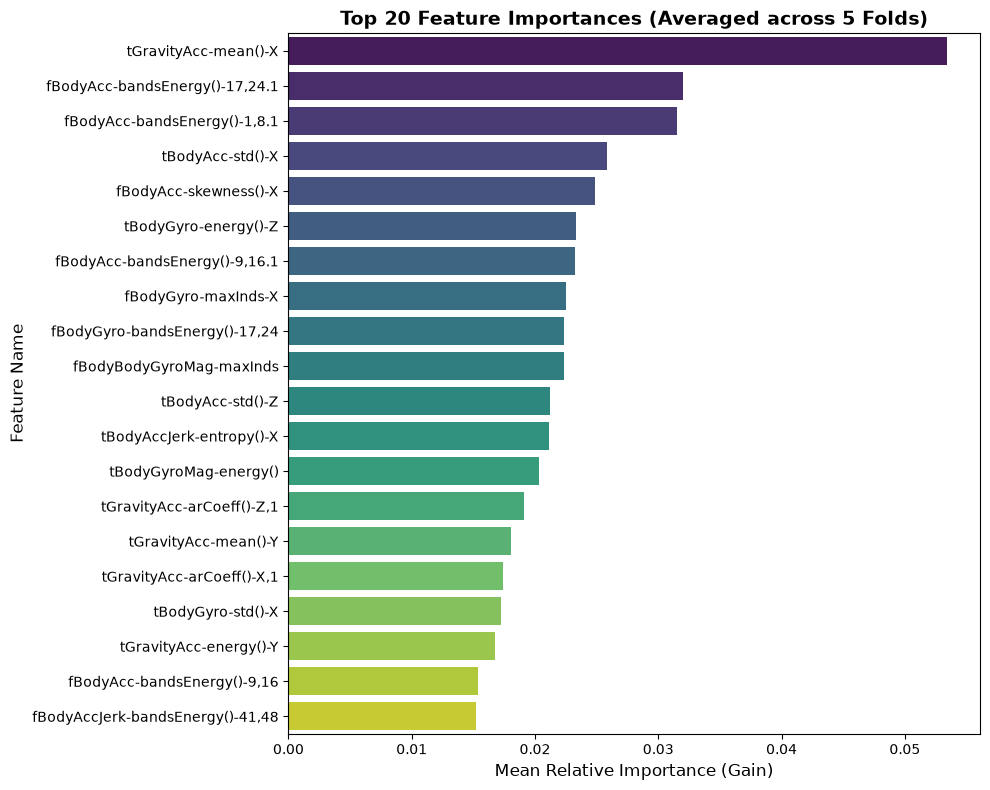

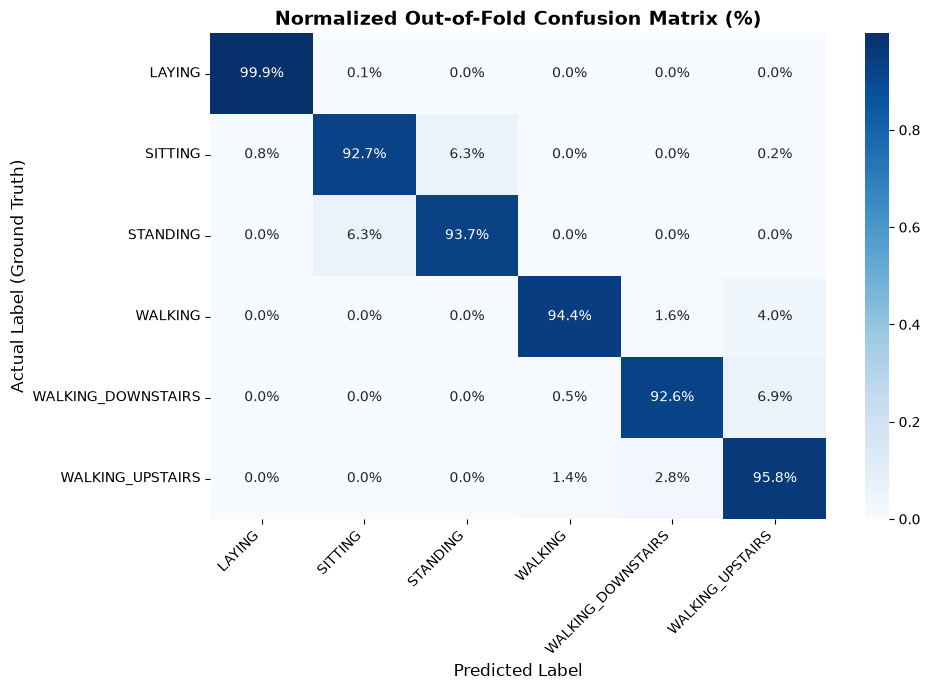

In [1]:
import os
import json
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.metrics import accuracy_score, confusion_matrix
import xgboost as xgb

note_for_docs = "30% test, 70% train (with internal val set for early stopping). 5 fold GroupKFold."

def log_experiment(params, accuracy, cm_normalized, labels, filepath="experiment_logs.jsonl", mode="jsonl"):
    """
    Logs hyperparameter tuning runs to either JSON Lines or CSV.
    """
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    if mode == "jsonl":
        cm_dict = {
            actual: {pred: round(float(cm_normalized[i, j] * 100), 2) 
                     for j, pred in enumerate(labels)}
            for i, actual in enumerate(labels)
        }
        
        entry = {
            "timestamp": timestamp,
            "accuracy": round(float(accuracy), 4),
            "hyperparameters": params,
            "confusion_matrix_pct": cm_dict,
            "note": note_for_docs
        }
        
        os.makedirs(os.path.dirname(filepath), exist_ok=True) if os.path.dirname(filepath) else None
        with open(filepath, "a") as f:
            f.write(json.dumps(entry) + "\n")
        print(f"Logged run to {filepath} (JSONL)")

    elif mode == "csv":
        row = {
            "timestamp": timestamp,
            "accuracy": round(float(accuracy), 4),
            **{f"param_{k}": v for k, v in params.items()}
        }
        
        for i, actual in enumerate(labels):
            for j, pred in enumerate(labels):
                col_name = f"cm_{actual}_{pred}"
                row[col_name] = round(float(cm_normalized[i, j] * 100), 2)
        
        df_row = pd.DataFrame([row])
        file_exists = os.path.isfile(filepath)
        df_row.to_csv(filepath, mode="a", index=False, header=not file_exists)
        print(f"Logged run to {filepath} (CSV)")


# 1. Pipeline-Safe Correlation Filter
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.95):
        self.threshold = threshold
        self.to_drop_indices_ = []

    def fit(self, X, y=None):
        df_x = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        corr_matrix = df_x.corr().abs()
        
        upper_tri = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        
        self.to_drop_indices_ = [
            i for i, col in enumerate(upper_tri.columns) 
            if any(upper_tri[col] > self.threshold)
        ]
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            return X.drop(X.columns[self.to_drop_indices_], axis=1).values
        return np.delete(X, self.to_drop_indices_, axis=1)


def get_pipeline_feature_names(pipeline, initial_feature_names):
    """
    Tracks surviving feature names through VarianceThreshold and CorrelationFilter.
    """
    current_features = list(initial_feature_names)
    
    if 'variance' in pipeline.named_steps:
        vt = pipeline.named_steps['variance']
        current_features = [f for f, keep in zip(current_features, vt.get_support()) if keep]
        
    if 'correlation' in pipeline.named_steps:
        cf = pipeline.named_steps['correlation']
        current_features = [f for i, f in enumerate(current_features) if i not in cf.to_drop_indices_]
        
    return current_features


# 2. Load and Prepare Data
df = pd.read_csv('../dataset/full_wo_fft.csv')

X = df.drop(columns=['Activity', 'subject'])
groups = df['subject']

le = LabelEncoder()
y = le.fit_transform(df['Activity'])
labels = le.classes_

param = {
    'learning_rate': 0.05,
    'max_depth': 6,
    'n_estimators': 1000,          # Set higher since early stopping will halt training
    'early_stopping_rounds': 20,   # Stops if eval_metric doesn't improve for 20 rounds
    'subsample': 0.6,
    'colsample_bytree': 0.7,
    'min_child_weight': 7,
    'reg_lambda': 5.0,
    'reg_alpha': 0,
    'gamma': 0.2,
    'eval_metric': 'mlogloss',
    'random_state': 69
}

# 3. Define Pipeline Steps up to Classifier
feature_pipeline = Pipeline([
    ('variance', VarianceThreshold(threshold=0.01)),
    ('correlation', CorrelationFilter(threshold=0.95))
])

# 4. Out-of-Fold Validation Loop with Internal Validation Split
gkf = GroupKFold(n_splits=5)
# GroupShuffleSplit ensures subjects in subtrain & val don't leak into each other
internal_gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=69)

y_true_all = []
y_pred_all = []
test_scores = []
train_scores = []
fold_feature_importances = []
best_iterations = []

print("Running 5-fold cross-validation with early stopping...\n")

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    X_train_fold, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test = y[train_idx], y[test_idx]
    groups_train_fold = groups.iloc[train_idx]
    
    # Split the fold's training data into Sub-train (80%) and Validation (20%) by subject
    subtrain_idx, val_idx = next(internal_gss.split(X_train_fold, y_train_fold, groups_train_fold))
    
    X_subtrain, X_val = X_train_fold.iloc[subtrain_idx], X_train_fold.iloc[val_idx]
    y_subtrain, y_val = y_train_fold[subtrain_idx], y_train_fold[val_idx]
    
    # Fit feature preprocessing ONLY on sub-train
    X_subtrain_transformed = feature_pipeline.fit_transform(X_subtrain, y_subtrain)
    X_val_transformed = feature_pipeline.transform(X_val)
    X_test_transformed = feature_pipeline.transform(X_test)
    
    # Initialize XGBoost model
    model = xgb.XGBClassifier(**param)
    
    # Fit with early stopping on transformed validation set
    model.fit(
        X_subtrain_transformed, 
        y_subtrain,
        eval_set=[(X_val_transformed, y_val)],
        verbose=False
    )
    
    best_iterations.append(model.best_iteration)
    
    # Evaluate
    train_acc = accuracy_score(y_subtrain, model.predict(X_subtrain_transformed))
    preds = model.predict(X_test_transformed)
    test_acc = accuracy_score(y_test, preds)
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    
    y_true_all.extend(y_test)
    y_pred_all.extend(preds)
    
    # Extract Feature Importances
    surviving_features = get_pipeline_feature_names(feature_pipeline, X.columns)
    fold_fi = pd.Series(model.feature_importances_, index=surviving_features)
    fold_feature_importances.append(fold_fi)
    
    print(f"Fold {fold+1}: Stopped at tree {model.best_iteration} | Train Acc = {train_acc:.4f}, Test Acc = {test_acc:.4f}")

mean_test_acc = np.mean(test_scores)
std_test_acc = np.std(test_scores)

print("-" * 40)
print(f"Average Best Iteration: {int(np.mean(best_iterations))}")
print(f"Average Test Accuracy: {mean_test_acc:.4f} (+/- {std_test_acc:.4f})")

# 5. Calculate Out-of-Fold Confusion Matrix
cm_normalized = confusion_matrix(y_true_all, y_pred_all, normalize='true')

# 6. Log Experiment
log_experiment(
    params=param,
    accuracy=mean_test_acc,
    cm_normalized=cm_normalized,
    labels=labels,
    filepath="../dataset/experiment_logs.jsonl",
    mode="jsonl"
)

# 7. Aggregate and Output Feature Importances
df_fi = pd.concat(fold_feature_importances, axis=1).fillna(0)
mean_fi = df_fi.mean(axis=1).sort_values(ascending=False)

print("\nTop 20 Most Important Features:")
print(mean_fi.head(20))

# 8. Plot Top Feature Importances
plt.figure(figsize=(10, 8))
sns.barplot(x=mean_fi.head(20).values, y=mean_fi.head(20).index, palette='viridis')
plt.title('Top 20 Feature Importances (Averaged across 5 Folds)', fontsize=14, fontweight='bold')
plt.xlabel('Mean Relative Importance (Gain)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()

# 9. Plot Confusion Matrix Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_normalized, 
    annot=True, 
    fmt='.1%', 
    cmap='Blues', 
    xticklabels=labels, 
    yticklabels=labels
)

plt.title('Normalized Out-of-Fold Confusion Matrix (%)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label (Ground Truth)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [2]:
# 1. Define the hyperparameter search space
# Use 'step_name__parameter_name' syntax to target pipeline steps
param_distributions = {
    # XGBoost Regularization & Tree Structure
    'xgb__n_estimators': [100, 200, 300, 500],
    'xgb__max_depth': [2, 3, 4, 6],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.6, 0.7, 0.8],
    'xgb__colsample_bytree': [0.6, 0.7, 0.8],
    'xgb__min_child_weight': [3, 5, 7, 10],
    'xgb__gamma': [0, 0.1, 0.2, 0.5],          # Minimum loss reduction for split
    'xgb__reg_alpha': [0, 0.1, 1.0],            # L1 regularization
    'xgb__reg_lambda': [0.1, 1.0, 5.0]          # L2 regularization
}

# 2. Set up RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=30,             # Evaluates 30 random parameter configurations
    scoring='f1_macro',  # Macro-averaged F1 score (higher is better)
    cv=gss,                # Uses your 5-fold GroupShuffleSplit
    return_train_score=True,
    random_state=69,
    n_jobs=-1
)

# 3. Fit search across subjects
search.fit(X, y, groups=groups)

# 4. View Best Parameters & Results
print("Best Hyperparameters:")
for param, val in search.best_params_.items():
    print(f"  {param}: {val}")

print(f"\nBest CV Test Accuracy: {search.best_score_:.4f}")

NameError: name 'RandomizedSearchCV' is not defined